# 4장 1강: 단순선형회귀 이론 — 실습문제

## 실습 목표

- 최소제곱법의 공식을 이용해 단순선형회귀의 기울기와 절편을 직접 계산합니다.
- 회귀계수, 예측값, 잔차, SSE, SST, 결정계수 $R^2$의 의미를 설명합니다.
- 회귀선과 잔차 플롯을 함께 확인하여 모델의 설명력과 적합 타당성을 평가합니다.

## 실습 환경 / 데이터

- Python, NumPy, pandas, Matplotlib
- `data/ames_housing.csv`
- 주요 변수: `SalePrice`, `GrLivArea`, `YearBuilt`
- 이번 강의는 회귀 원리를 확인하는 과정이므로 회귀계수와 평가지표를 NumPy로 직접 계산합니다.

## 실습 준비

아래 셀을 실행하여 데이터를 불러오고 데이터 크기, 결측치, 컬럼을 확인하세요.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
if "Malgun Gothic" in {f.name for f in font_manager.fontManager.ttflist}:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

data_candidates = [
    Path("data/ames_housing.csv"),
    Path("ames_housing(1).csv"),
    Path("ames_housing.csv"),
    Path("upload/ames_housing(1).csv"),
]
data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("ames_housing CSV 파일을 노트북과 같은 폴더에 넣어주세요.")

df = pd.read_csv(data_path)

print(f"데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print("전체 결측치 수:", int(df.isna().sum().sum()))
print("컬럼:", df.columns.tolist())
df.head()


데이터 크기: 1460행, 10열
전체 결측치 수: 0
컬럼: ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'KitchenQual', 'CentralAir', 'HeatingQC', 'PavedDrive', 'Neighborhood', 'YearBuilt']


,SalePrice,GrLivArea,LotArea,OverallQual,KitchenQual,CentralAir,HeatingQC,PavedDrive,Neighborhood,YearBuilt
0,208500,1710,8450,7,Gd,Y,Ex,Y,CollgCr,2003
1,181500,1262,9600,6,TA,Y,Ex,Y,Veenker,1976
2,223500,1786,11250,7,Gd,Y,Ex,Y,CollgCr,2001
3,140000,1717,9550,7,Gd,Y,Gd,Y,Crawfor,1915
4,250000,2198,14260,8,Gd,Y,Ex,Y,NoRidge,2000


---

## 필수 1. 생활면적으로 매매가격을 설명하는 회귀직선 구하기

`GrLivArea`를 독립변수 $x$, `SalePrice`를 종속변수 $y$로 사용하여 최소제곱 회귀직선을 직접 구하세요.

### 수행 요구사항

1. 두 변수의 결측치를 제거한 분석용 데이터를 만드세요.
2. $x$와 $y$의 평균을 계산하세요.
3. 아래 공식을 이용하여 기울기 $\beta_1$과 절편 $\beta_0$를 계산하세요.

$$
\beta_1 = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum (x_i-\bar{x})^2},
\qquad
\beta_0 = \bar{y}-\beta_1\bar{x}
$$

4. 회귀식을 출력하고, 생활면적이 1,500일 때의 매매가격을 예측하세요.
5. 산점도 위에 회귀직선을 그리세요.

### 질문

- 기울기 $\beta_1$은 이 데이터에서 무엇을 의미하나요?
- 절편 $\beta_0$는 무엇을 의미하며, 현실적으로 그대로 해석해도 되나요?
- 최소제곱법은 어떤 기준으로 이 회귀직선을 선택하나요?


x 평균=1515.4637, y 평균=180921.1959
예측가격 = 18569.0259 + 107.1304 × GrLivArea
생활면적 1,500 sq ft의 예측가격: 179,264.56달러


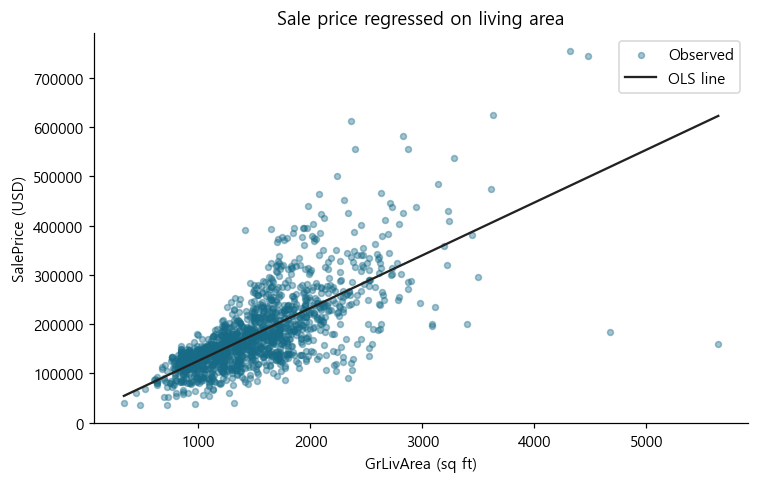

In [2]:
reg_data = df[["GrLivArea", "SalePrice"]].dropna()
x = reg_data.GrLivArea.to_numpy(dtype=float)
y = reg_data.SalePrice.to_numpy(dtype=float)
x_mean, y_mean = x.mean(), y.mean()
beta1 = np.sum((x-x_mean)*(y-y_mean)) / np.sum((x-x_mean)**2)
beta0 = y_mean - beta1*x_mean
print(f"x 평균={x_mean:.4f}, y 평균={y_mean:.4f}")
print(f"예측가격 = {beta0:.4f} + {beta1:.4f} × GrLivArea")
print(f"생활면적 1,500 sq ft의 예측가격: {beta0+beta1*1500:,.2f}달러")
fig, ax = plt.subplots(figsize=(7,4.5))
ax.scatter(x,y,s=15,alpha=0.4,color="#176B87",label="Observed")
line_x = np.array([x.min(),x.max()])
ax.plot(line_x,beta0+beta1*line_x,color="#222222",label="OLS line")
ax.set(xlabel="GrLivArea (sq ft)",ylabel="SalePrice (USD)",title="Sale price regressed on living area")
ax.legend()
fig.tight_layout()
plt.show()


### 필수 1 답변

- **기울기:** 생활면적이 1 sq ft 클 때 예측 매매가격은 약 107.13달러 높습니다. 다른 조건을 통제한 인과효과가 아니라 이 표본의 선형 연관성입니다.
- **절편:** 18,569.03달러는 면적이 0일 때 직선이 주는 예측입니다. 0은 관측 범위 밖이므로 현실적인 주택가격으로 해석하지 않습니다. 면적 1,500의 예측은 179,264.56달러입니다.
- **최소제곱법:** 모든 관측치의 실제가격과 예측가격 차이의 제곱합(SSE)을 최소화하는 직선을 선택합니다.

---

## 필수 2. 결정계수와 잔차로 회귀모델 평가하기

필수 1에서 구한 `beta0`, `beta1`, `x`, `y`를 이용하여 모델의 설명력과 잔차 분포를 평가하세요.

### 수행 요구사항

1. 예측값 $\hat{y}$과 잔차 $e=y-\hat{y}$를 계산하세요.
2. SSE와 SST를 계산한 뒤 $R^2=1-SSE/SST$를 구하세요.
3. 잔차의 평균과 평균절대잔차(MAE)를 계산하세요.
4. 예측값을 x축, 잔차를 y축으로 하는 잔차 플롯을 그리세요. $y=0$ 기준선을 표시하세요.
5. 절대잔차가 가장 큰 관측치의 생활면적, 실제가격, 예측가격, 잔차를 출력하세요.

### 질문

- $R^2$은 이 모델에서 무엇을 의미하나요?
- 잔차 평균이 0에 가깝다는 사실만으로 좋은 모델이라고 판단할 수 있나요?
- 잔차 플롯에서 오차의 폭과 극단적인 잔차는 어떻게 보이나요?
- 회귀계수, $R^2$, 잔차를 종합할 때 이 모델은 매매가격을 충분히 설명한다고 볼 수 있나요?


SSE=4,584,171,086,113.13, SST=9,207,911,334,609.98, R²=0.502149
잔차 평균=0.0000000000, MAE=37,638.73달러


,원본 행 인덱스,생활면적,실제가격,예측가격,잔차
0,1298,5642.0,160000.0,622998.511142,-462998.511142


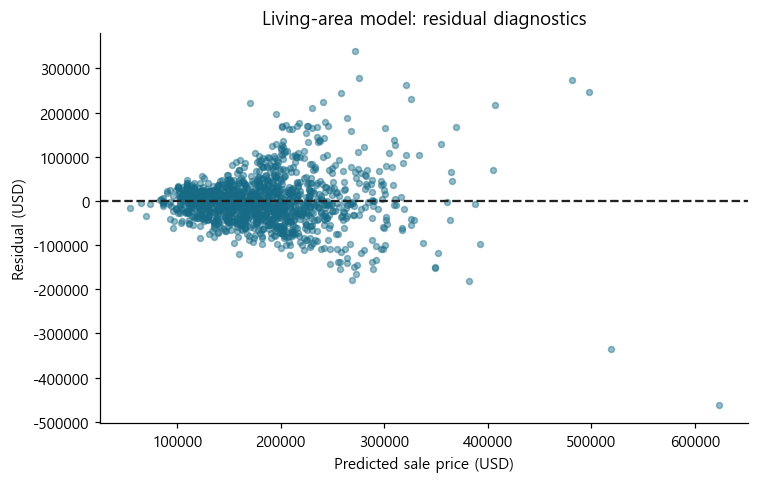

In [3]:
y_hat = beta0 + beta1*x
residuals = y-y_hat
SSE = np.sum(residuals**2)
SST = np.sum((y-y.mean())**2)
R2 = 1-SSE/SST
MAE = np.mean(np.abs(residuals))
print(f"SSE={SSE:,.2f}, SST={SST:,.2f}, R²={R2:.6f}")
print(f"잔차 평균={residuals.mean():.10f}, MAE={MAE:,.2f}달러")
assert np.isclose(R2,np.corrcoef(x,y)[0,1]**2)
assert np.isclose(residuals.mean(),0,atol=1e-7)
worst = np.argmax(np.abs(residuals))
display(pd.DataFrame({"원본 행 인덱스": [reg_data.index[worst]], "생활면적": [x[worst]],
    "실제가격": [y[worst]], "예측가격": [y_hat[worst]], "잔차": [residuals[worst]]}))
fig,ax=plt.subplots(figsize=(7,4.5))
ax.scatter(y_hat,residuals,s=15,alpha=0.45,color="#176B87")
ax.axhline(0,color="#222222",linestyle="--")
ax.set(xlabel="Predicted sale price (USD)",ylabel="Residual (USD)",title="Living-area model: residual diagnostics")
fig.tight_layout()
plt.show()


### 필수 2 답변

- **R²:** 0.5021로 이 표본의 매매가격 변동 약 50.21%를 설명합니다. 미래 자료에서 같은 성능을 보장하지 않습니다.
- **평균 잔차:** 절편이 포함된 OLS에서는 잔차 합이 수치 오차 범위에서 0이 됩니다. 양·음 오차가 상쇄되므로 평균≈0만으로 좋은 모델이라고 할 수 없습니다.
- **잔차 플롯:** 예측가격에 따라 오차 폭이 일정하지 않고 큰 음의 잔차가 나타납니다. 최대 절대잔차 관측치의 면적·실제가격·예측가격을 위 표에서 확인할 수 있습니다.
- **종합:** 양의 기울기와 상당한 설명력은 있으나 MAE가 37,638.73달러이고 설명되지 않는 변동도 큽니다. 정확한 개별 주택 평가에는 위치·품질 등 추가 정보와 별도 검증 자료가 필요합니다.

---

## 과제. 건축연도로 매매가격을 설명하는 단순회귀 분석

`YearBuilt`를 독립변수, `SalePrice`를 종속변수로 사용하여 필수 문제와 동일한 수준의 단순선형회귀 분석을 독립적으로 수행하세요.

### 수행 요구사항

1. 최소제곱법으로 기울기와 절편을 직접 계산하세요.
2. 예측값, 잔차, SSE, SST, $R^2$을 계산하세요.
3. 건축연도가 2000년인 주택의 매매가격을 예측하세요.
4. 산점도와 회귀직선, 잔차 플롯을 그리세요.
5. 아래 질문에 답하는 5~7문장의 결론을 작성하세요.

### 질문

- 기울기와 절편은 각각 무엇을 의미하나요?
- $R^2$을 기준으로 모델의 설명력은 어떠한가요?
- 잔차 플롯을 기준으로 모델의 적합성에 주의할 점이 있나요?
- 이 모델의 적용 한계 또는 개선 방향을 한 가지 이상 제시하세요.

> 과제는 필수 문제와 동일한 수준이며, 새로운 고급 기법을 사용할 필요는 없습니다.


예측가격 = -2530308.2457 + 1375.3735 × YearBuilt
SSE=6,690,269,293,939.84, SST=9,207,911,334,609.98, R²=0.273422
2000년 건축 주택 예측가격: 220,438.69달러


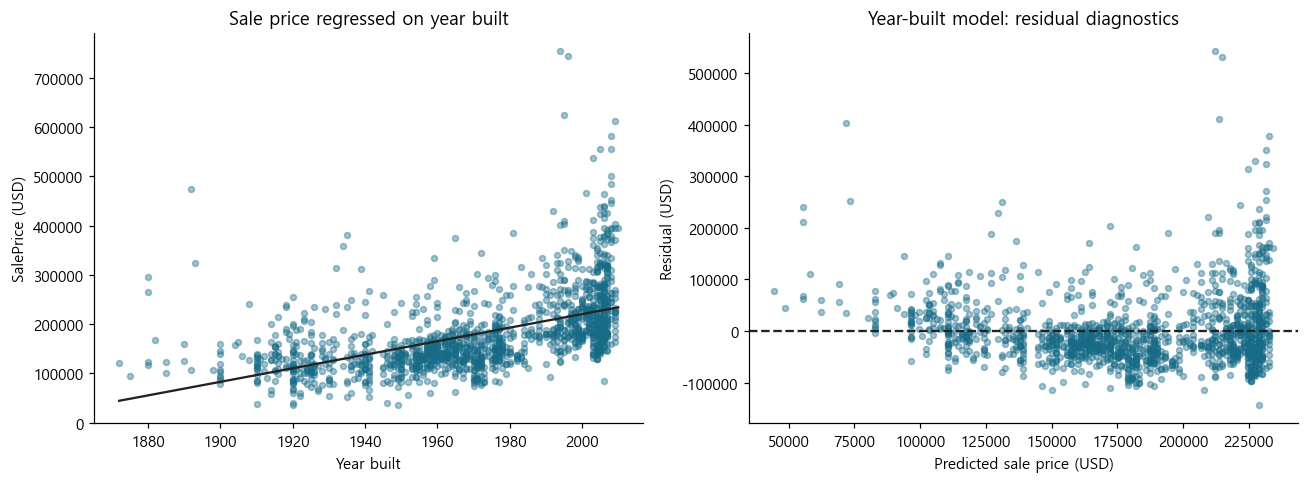

In [4]:
year_data = df[["YearBuilt", "SalePrice"]].dropna()
x_year = year_data.YearBuilt.to_numpy(dtype=float)
y_year = year_data.SalePrice.to_numpy(dtype=float)
beta1_year = np.sum((x_year-x_year.mean())*(y_year-y_year.mean())) / np.sum((x_year-x_year.mean())**2)
beta0_year = y_year.mean()-beta1_year*x_year.mean()
pred_year = beta0_year+beta1_year*x_year
res_year = y_year-pred_year
SSE_year = np.sum(res_year**2)
SST_year = np.sum((y_year-y_year.mean())**2)
R2_year = 1-SSE_year/SST_year
print(f"예측가격 = {beta0_year:.4f} + {beta1_year:.4f} × YearBuilt")
print(f"SSE={SSE_year:,.2f}, SST={SST_year:,.2f}, R²={R2_year:.6f}")
print(f"2000년 건축 주택 예측가격: {beta0_year+beta1_year*2000:,.2f}달러")
fig, axes = plt.subplots(1,2,figsize=(12,4.5))
axes[0].scatter(x_year,y_year,s=15,alpha=0.4,color="#176B87")
line_year = np.array([x_year.min(),x_year.max()])
axes[0].plot(line_year,beta0_year+beta1_year*line_year,color="#222222")
axes[0].set(xlabel="Year built",ylabel="SalePrice (USD)",title="Sale price regressed on year built")
axes[1].scatter(pred_year,res_year,s=15,alpha=0.4,color="#176B87")
axes[1].axhline(0,color="#222222",linestyle="--")
axes[1].set(xlabel="Predicted sale price (USD)",ylabel="Residual (USD)",title="Year-built model: residual diagnostics")
fig.tight_layout()
plt.show()


### 과제 결론 (6문장)

건축연도 모형의 기울기는 1375.37로, 건축연도가 1년 늦은 주택은 예측가격이 약 1375.37달러 높습니다.
절편 -2,530,308.25달러는 서기 0년의 형식적 예측으로 관측 범위를 크게 벗어나 현실적으로 해석하지 않습니다.
2000년 건축 주택의 예측가격은 220,438.69달러입니다.
R²=0.2734로 가격 변동의 약 27.34%를 설명하므로 건축연도 하나만으로는 설명력이 제한적입니다.
잔차 플롯에는 큰 양의 잔차와 일정하지 않은 오차 폭이 보여 직선과 일정한 오차 분산만으로 자료를 충분히 표현하기 어렵습니다.
면적·위치·품질을 추가로 고려하고 별도 자료로 예측오차를 검증해야 하며, 이 관측상 관계를 신축의 인과효과나 관측 범위 밖 가격 예측으로 확대하면 안 됩니다.

---

## 실습 마무리

- 어떤 문제가 있었는가?
- 어떻게 개선했는가?
- 무엇을 근거로 개선되었다고 판단했는가?

$R^2$만 확인했을 때 놓칠 수 있는 점과 잔차 플롯을 추가했을 때 새롭게 확인한 내용을 중심으로 정리하세요.

### 마무리 답변

1. R²만 확인하면 오차 크기·극단 관측치·분산의 불균일성·외삽 문제를 놓칠 수 있었습니다.

2. 회귀선을 원래 자료에 겹치고 예측값 대 잔차 플롯, MAE 및 최대 절대잔차 관측치를 함께 확인했습니다.

3. 생활면적 모델은 R²=0.5021지만 MAE=37,638.73달러이고 큰 음의 잔차가 존재합니다. 잔차 평균≈0은 절편 포함 OLS의 성질일 뿐 좋은 예측의 증거가 아닙니다. 진단을 보완했으며 모델 자체의 예측력이 개선된 것은 아닙니다.
